In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
print(df.head())
print(df.info())
print(df.columns)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
Index(['CustomerID', 'Gender', 'Age', 'Annual Incom

In [5]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

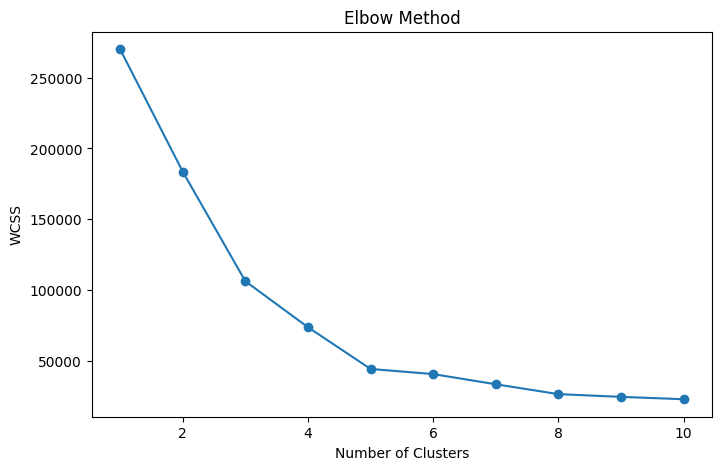

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

y_kmeans = kmeans.fit_predict(X)

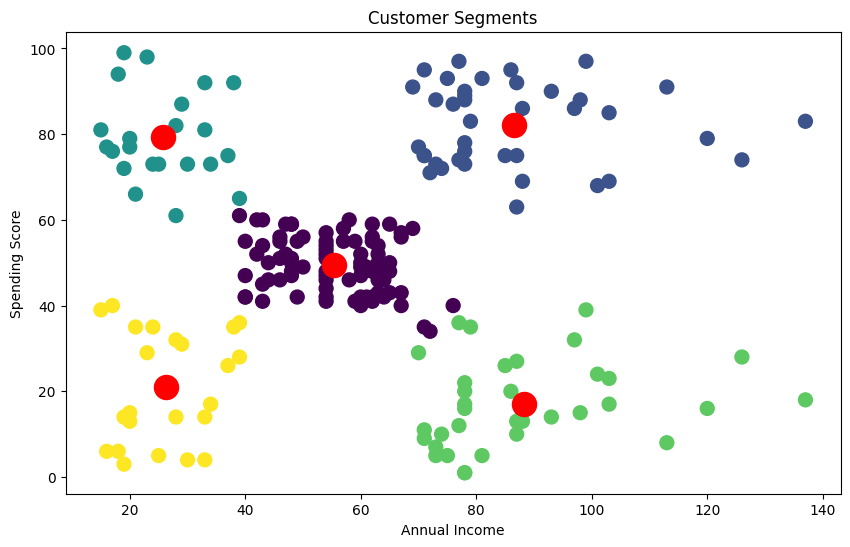

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, s=100)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')

plt.show()

#Blue Cluster → Premium Customers
#Green Cluster → Conservative Customers
#Purple Cluster → Standard Customers
#Yellow Cluster → Budget Customers
#Cyan Cluster → Impulsive Customers
#Red Points → Centroids

#**CONCLUSION**
**Customer segmentation helps businesses identify different customer groups based on purchasing behavior and income patterns. These insights can improve targeted marketing and customer retention strategies.**